# BO Forge simulated campaign

This notebook demonstrates the real MVP v0.1 workflow one experiment at a time. Each cycle requests one candidate, appends it as `status=suggested`, simulates the lab result, marks that same row as `status=observed`, reloads the CSV log, and only then requests the next candidate.

## 1. Setup

The example config still has `batch_size: 3`, but this notebook deliberately overrides suggestions to `batch_size=1` so the workflow mirrors a sequential lab campaign.

In [1]:
from pathlib import Path
import os
import shutil
import sys

import numpy as np
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
mpl_cache = PROJECT_ROOT / ".matplotlib-cache"
mpl_cache.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from bo_forge import CampaignConfig, append_suggestions, load_campaign_log, mark_observed, suggest_next
from bo_forge.diagnostics import plot_diagnostics, plot_progress
from bo_forge.validation import get_observed_data, validate_campaign_data

In [2]:
config_path = PROJECT_ROOT / "configs" / "simple_2d.yaml"
seed_log_path = PROJECT_ROOT / "examples" / "simple_2d_campaign_log.csv"
working_log_path = PROJECT_ROOT / "examples" / "simple_2d_working_log.csv"
latest_suggestion_path = PROJECT_ROOT / "examples" / "latest_suggestions.csv"

shutil.copyfile(seed_log_path, working_log_path)

config = CampaignConfig.from_yaml(config_path)
one_at_a_time_batch_size = 1

In [3]:
def simulated_activity(row) -> float:
    ratio = float(row["precursor_ratio"])
    temperature = float(row["annealing_temperature"])
    smooth_peak = 2.2 - 4.0 * (ratio - 0.62) ** 2
    smooth_peak -= ((temperature - 710.0) / 170.0) ** 2
    small_wave = 0.04 * np.sin(10.0 * ratio)
    small_wave += 0.03 * np.cos(temperature / 55.0)
    return float(smooth_peak + small_wave)


def current_log():
    df = load_campaign_log(working_log_path, config)
    validate_campaign_data(config, df)
    return df


def request_one_candidate():
    df = current_log()
    suggestion = suggest_next(config, df, batch_size=one_at_a_time_batch_size)
    suggestion.to_csv(latest_suggestion_path, index=False)
    append_suggestions(working_log_path, suggestion)
    return suggestion


def enter_simulated_result(suggestion):
    row = suggestion.iloc[0]
    result = simulated_activity(row)
    mark_observed(working_log_path, str(row["row_id"]), result)
    return result

## 2. Load the current campaign log

The campaign starts from two manually observed experiments. The remaining initial-design points will be suggested one at a time using Sobol.

In [4]:
df = current_log()
df

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,manual_000,0,observed,manual,0.2,500,1.34,,,
1,manual_001,0,observed,manual,0.7,650,1.82,,,


## 3. Request one initial candidate

In [5]:
suggestion = request_one_candidate()
suggestion

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,79f566ea1096454cb75ed114abff793b,1,suggested,sobol,0.472047,795.296508,,,,


## 4. Enter the result for that one experiment

In a real campaign, replace `simulated_activity(...)` with the measured lab result, then call `mark_observed(...)` for the same `row_id`.

In [6]:
result = enter_simulated_result(suggestion)
df = current_log()
print("Entered result:", result)
df.tail(3)

Entered result: 1.8111778742027098


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,manual_000,0,observed,manual,0.200000,500.000000,1.340000,,,
1,manual_001,0,observed,manual,0.700000,650.000000,1.820000,,,
2,79f566ea1096454cb75ed114abff793b,1,observed,sobol,0.472047,795.296508,1.811178,,,


## 5. Repeat the same one-experiment cycle

Each cell below represents one lab iteration: suggest one candidate, run one experiment, enter one result, reload the log.

In [7]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
display(suggestion)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,c61942d0240d4a10b75cbbd50929a8d5,2,suggested,sobol,0.910286,478.744927,,,,


Entered result: 0.002561283491411973


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
3,c61942d0240d4a10b75cbbd50929a8d5,2,observed,sobol,0.910286,478.744927,0.002561,,,


In [8]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
display(suggestion)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,ae4797b3b7f842b694c686ded7f21bab,3,suggested,sobol,0.517631,569.10913,,,,


Entered result: 1.4173397552958444


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
4,ae4797b3b7f842b694c686ded7f21bab,3,observed,sobol,0.517631,569.10913,1.41734,,,


In [9]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
display(suggestion)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,a84cb72d205d45d9b44c2442638bc4f8,4,suggested,sobol,0.083311,393.470521,,,,


Entered result: -2.3700258156251692


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
5,a84cb72d205d45d9b44c2442638bc4f8,4,observed,sobol,0.083311,393.470521,-2.370026,,,


In [10]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
display(suggestion)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,29fb5d697da4423f8ec1b5683da190bb,5,suggested,sobol,0.203096,674.482185,,,,


Entered result: 1.5255866339657844


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
6,29fb5d697da4423f8ec1b5683da190bb,5,observed,sobol,0.203096,674.482185,1.525587,,,


In [11]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
display(suggestion)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,eb0fcf1193ba43cd9bdf8e45c14029a3,6,suggested,sobol,0.633526,350.169606,,,,


Entered result: -2.2489590768214742


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
7,eb0fcf1193ba43cd9bdf8e45c14029a3,6,observed,sobol,0.633526,350.169606,-2.248959,,,


## 6. Now the initial design is complete

Once the number of observed rows reaches `initial_design_size`, the next call fits the GP and uses LogEI because this notebook requests one candidate at a time.

In [12]:
df = current_log()
len(get_observed_data(config, df)), config.bo.initial_design_size

(8, 8)

In [13]:
suggestion = request_one_candidate()
suggestion

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,b9d153cbce534b2f8f5f8be9358c78a9,7,suggested,log_ei,1.0,723.627666,,1.96824,0.923904,-0.804216


In [14]:
result = enter_simulated_result(suggestion)
df = current_log()
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

Entered result: 1.619133028587096


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
8,b9d153cbce534b2f8f5f8be9358c78a9,7,observed,log_ei,1.0,723.627666,1.619133,1.9682399455886144,0.9239038565971786,-0.8042160487324732


## 7. Diagnostics

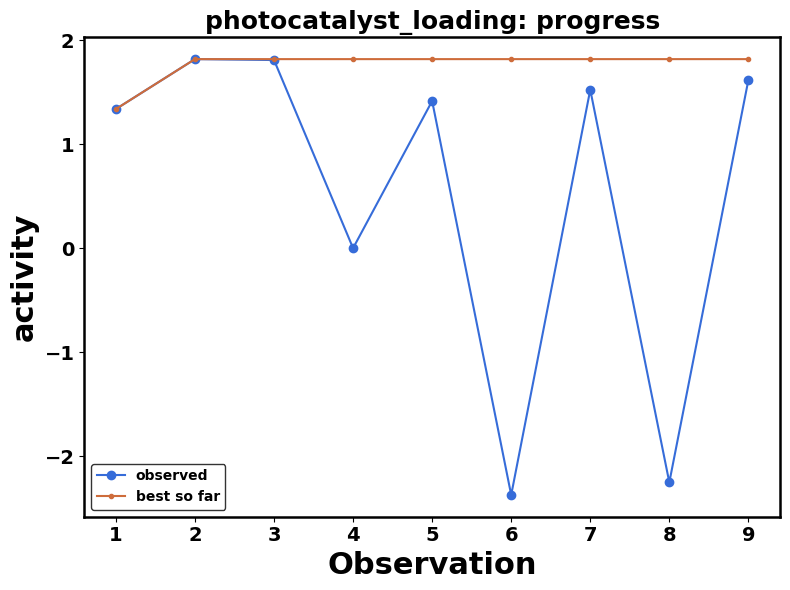

In [15]:
plot_progress(config, df);

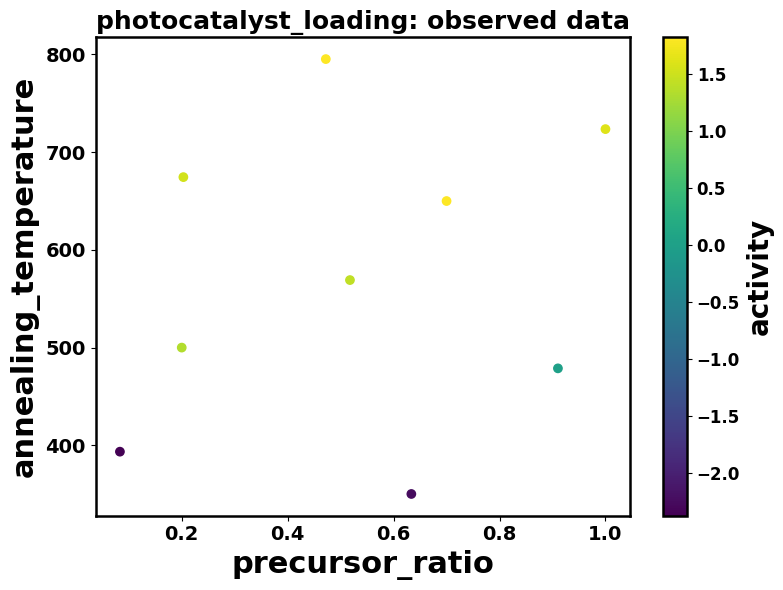

In [16]:
plot_diagnostics(config, df);